
# Monte Carlo EM for MMIL-Inspired Cell-Level Stage Inference in scRNA-seq

This notebook is a **Python conversion and reorganization** of the R pipeline scripts for the GSE131907 lung cancer single-cell project.

The goal is to infer **latent cell-level stage-associated probabilities** from **patient-level cancer stage labels**.

Main workflow:

1. Explore stage and cell-type composition.
2. Load or create the PCA-based modeling table.
3. Fit binary Early vs Advanced models:
   - Naive inherited-label baseline
   - Deterministic EM-MMIL
   - MCEM-MMIL
   - Paper-style noisy-OR MMIL
4. Aggregate cell-level probabilities to patient-level scores.
5. Extend the framework to categorical stage labels: Stage I, Stage II/III, Stage IV.

The long backend functions are hidden/collapsed to keep the notebook readable.



## 0. Setup

Edit `project_dir` if needed. The notebook expects input files in `Data/` and writes outputs to `Results/`.


In [ ]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy.optimize import minimize
from scipy.special import expit, logsumexp, softmax

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 2026
rng = np.random.default_rng(RANDOM_STATE)

project_dir = Path("your/project/directory/here")  # <-- Update this to your actual project directory
data_dir = project_dir / "Data"
results_dir = project_dir / "Results"
figures_dir = results_dir / "Figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)
print("Data directory:", data_dir)
print("Results directory:", results_dir)


Project directory: D:\Monte\Monte-Carlo-Method-Project-Group-4
Data directory: D:\Monte\Monte-Carlo-Method-Project-Group-4\Data
Results directory: D:\Monte\Monte-Carlo-Method-Project-Group-4\Results



## 1. Helper functions

This cell contains reusable modeling, evaluation, and plotting functions. It is hidden/collapsed because it is backend code.


In [97]:

# ============================================================
# General helper functions
# ============================================================

EPS = 1e-8


def safe_log_loss(y, p, eps=1e-8):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    y = np.asarray(y, dtype=int)
    return float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())


def safe_auc(y, score):
    y = np.asarray(y)
    score = np.asarray(score)
    if len(np.unique(y)) < 2 or len(np.unique(score)) < 2:
        return np.nan
    return float(roc_auc_score(y, score))


def split_patients_stratified(df, patient_col, label_col, test_frac=0.25, random_state=2026):
    """Create a train/test split by patient, stratified by patient-level labels."""
    patients = df[[patient_col, label_col]].drop_duplicates().reset_index(drop=True)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=random_state)
    idx_train, idx_test = next(splitter.split(patients[[patient_col]], patients[label_col]))
    test_patients = set(patients.loc[idx_test, patient_col])
    out = df.copy()
    out["split"] = np.where(out[patient_col].isin(test_patients), "test", "train")
    return out


def split_train_validation_by_patient(df, patient_col, label_col, val_frac=0.20, random_state=2026):
    """Within training patients, create a subtrain/validation split."""
    out = df.copy()
    out["model_split"] = "test"
    train = out[out["split"] == "train"]
    patients = train[[patient_col, label_col]].drop_duplicates().reset_index(drop=True)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_frac, random_state=random_state)
    idx_sub, idx_val = next(splitter.split(patients[[patient_col]], patients[label_col]))
    val_patients = set(patients.loc[idx_val, patient_col])
    out.loc[out["split"] == "train", "model_split"] = "subtrain"
    out.loc[out[patient_col].isin(val_patients), "model_split"] = "validation"
    return out


def summarize_split(df, patient_col="Patient", label_col="Stage_group"):
    patient_summary = (
        df[[patient_col, label_col, "split"]]
        .drop_duplicates()
        .groupby(["split", label_col])
        .size()
        .reset_index(name="n_patients")
    )
    cell_summary = df.groupby(["split", label_col]).size().reset_index(name="n_cells")
    return patient_summary, cell_summary


# ============================================================
# Binary soft-label logistic regression with ridge penalty
# This replaces R glmnet soft-binomial fitting.
# ============================================================

class BinarySoftLogistic:
    def __init__(self, beta, scaler, lambda_ridge):
        self.beta = beta
        self.scaler = scaler
        self.lambda_ridge = lambda_ridge

    def predict_proba(self, X):
        Xs = self.scaler.transform(np.asarray(X, dtype=float))
        eta = self.beta[0] + Xs @ self.beta[1:]
        return np.clip(expit(eta), EPS, 1 - EPS)


def fit_binary_soft_logistic(X, y_soft, lambda_ridge=1e-2, init_beta=None, maxiter=500):
    X = np.asarray(X, dtype=float)
    y = np.clip(np.asarray(y_soft, dtype=float), EPS, 1 - EPS)
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)
    n, p = Xs.shape
    X_design = np.column_stack([np.ones(n), Xs])

    if init_beta is None:
        init_prob = np.clip(y.mean(), 1e-4, 1 - 1e-4)
        init_beta = np.zeros(p + 1)
        init_beta[0] = np.log(init_prob / (1 - init_prob))

    def objective(beta):
        eta = X_design @ beta
        prob = np.clip(expit(eta), EPS, 1 - EPS)
        nll = -(y * np.log(prob) + (1 - y) * np.log(1 - prob)).mean()
        penalty = 0.5 * lambda_ridge * np.sum(beta[1:] ** 2)
        value = nll + penalty
        grad = X_design.T @ (prob - y) / n
        grad[1:] += lambda_ridge * beta[1:]
        return value, grad

    res = minimize(
        fun=lambda b: objective(b)[0],
        x0=init_beta,
        jac=lambda b: objective(b)[1],
        method="BFGS",
        options={"maxiter": maxiter, "gtol": 1e-5},
    )
    return BinarySoftLogistic(res.x, scaler, lambda_ridge), res


def tune_binary_lambda(X, y, lambda_grid=None, random_state=2026):
    """Simple internal CV-like validation for ridge lambda."""
    if lambda_grid is None:
        lambda_grid = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
    y_bin = (np.asarray(y) > 0.5).astype(int)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
    tr_idx, va_idx = next(splitter.split(X, y_bin))
    rows = []
    best = None
    for lam in lambda_grid:
        model, res = fit_binary_soft_logistic(np.asarray(X)[tr_idx], np.asarray(y)[tr_idx], lambda_ridge=lam)
        pred = model.predict_proba(np.asarray(X)[va_idx])
        ll = safe_log_loss(y_bin[va_idx], pred)
        rows.append({"lambda": lam, "validation_logloss": ll, "converged": res.success})
        if best is None or ll < best[0]:
            best = (ll, lam)
    return best[1], pd.DataFrame(rows).sort_values("validation_logloss")


# ============================================================
# Binary EM-MMIL and MCEM-MMIL
# ============================================================


def fit_binary_naive_em_mcem(df, pc_cols, rho=0.70, max_iter=30, mcem_samples=20,
                             lambda_grid=None, random_state=2026):
    """
    Binary Early vs Advanced pipeline:
    - Naive inherited-label logistic baseline
    - Deterministic EM-MMIL
    - MCEM-MMIL
    """
    rng_local = np.random.default_rng(random_state)
    train = df[df["split"] == "train"].copy()
    test = df[df["split"] == "test"].copy()
    X_train = train[pc_cols].to_numpy(float)
    X_test = test[pc_cols].to_numpy(float)
    z_train = train["z_obs"].to_numpy(int)
    z_test = test["z_obs"].to_numpy(int)

    best_lambda, lambda_tuning = tune_binary_lambda(X_train, z_train, lambda_grid=lambda_grid, random_state=random_state)

    # Naive baseline
    naive_model, naive_res = fit_binary_soft_logistic(X_train, z_train, lambda_ridge=best_lambda)

    # Deterministic EM-MMIL
    y_soft = np.where(z_train == 1, 1 - rho, 0.0).astype(float)
    em_log = []
    em_model = None
    for it in range(1, max_iter + 1):
        old = y_soft.copy()
        em_model, _ = fit_binary_soft_logistic(X_train, y_soft, lambda_ridge=best_lambda)
        p_hat = em_model.predict_proba(X_train)
        adv_idx = z_train == 1
        early_idx = z_train == 0
        y_soft[early_idx] = 0.0
        p_adv = p_hat[adv_idx]
        current_mean = p_adv.mean() if p_adv.size else 0
        target_mean = 1 - rho
        if current_mean > 0:
            p_scaled = p_adv * target_mean / current_mean
        else:
            p_scaled = np.full(p_adv.shape, target_mean)
        y_soft[adv_idx] = np.clip(p_scaled, 1e-6, 1 - 1e-6)
        delta = np.mean(np.abs(y_soft - old))
        em_log.append({"iter": it, "delta": delta,
                       "mean_soft_advanced": y_soft[adv_idx].mean(),
                       "mean_prob_advanced": p_hat[adv_idx].mean()})
        if delta < 1e-4:
            break

    # MCEM-MMIL
    q_prob = np.where(z_train == 1, 1 - rho, 0.0).astype(float)
    mcem_log = []
    mcem_model = None
    for it in range(1, max_iter + 1):
        old = q_prob.copy()
        adv_idx = z_train == 1
        early_idx = z_train == 0
        sampled = np.zeros((len(z_train), mcem_samples), dtype=float)
        for m in range(mcem_samples):
            y_sample = np.zeros(len(z_train), dtype=float)
            y_sample[adv_idx] = rng_local.binomial(1, q_prob[adv_idx])
            y_sample[early_idx] = 0
            sampled[:, m] = y_sample
        y_mc_avg = sampled.mean(axis=1)
        mcem_model, _ = fit_binary_soft_logistic(X_train, y_mc_avg, lambda_ridge=best_lambda)
        p_hat = mcem_model.predict_proba(X_train)
        p_adv = p_hat[adv_idx]
        current_mean = p_adv.mean() if p_adv.size else 0
        target_mean = 1 - rho
        if current_mean > 0:
            p_scaled = p_adv * target_mean / current_mean
        else:
            p_scaled = np.full(p_adv.shape, target_mean)
        q_prob[early_idx] = 0.0
        q_prob[adv_idx] = np.clip(p_scaled, 1e-6, 1 - 1e-6)
        delta = np.mean(np.abs(q_prob - old))
        mcem_log.append({"iter": it, "delta": delta,
                         "mean_q_advanced": q_prob[adv_idx].mean(),
                         "mean_sampled_y_advanced": y_mc_avg[adv_idx].mean()})
        if delta < 1e-4:
            break

    # Predictions
    out = df.copy()
    X_all = out[pc_cols].to_numpy(float)
    out["naive_prob"] = naive_model.predict_proba(X_all)
    out["em_mmil_prob"] = em_model.predict_proba(X_all)
    out["mcem_mmil_prob"] = mcem_model.predict_proba(X_all)

    logs = {
        "lambda_tuning": lambda_tuning,
        "em_log": pd.DataFrame(em_log),
        "mcem_log": pd.DataFrame(mcem_log),
        "best_lambda": best_lambda,
    }
    models = {"naive": naive_model, "em": em_model, "mcem": mcem_model}
    return out, logs, models


# ============================================================
# Patient-level aggregation and metrics
# ============================================================


def aggregate_patient_scores(cell_pred, prob_cols, patient_col="Patient"):
    cell_pred = cell_pred.copy()

    # Avoid pandas categorical groupby expansion issues
    cell_pred["Stage_group"] = cell_pred["Stage_group"].astype(str)

    rows = []
    for model_name, col in prob_cols.items():
        agg = (
            cell_pred
            .groupby(
                ["split", patient_col, "Stage_group", "y_patient"],
                as_index=False,
                observed=True
            )
            .agg(
                n_cells=(col, "size"),
                mean_prob=(col, "mean"),
                median_prob=(col, "median"),
                q90_prob=(col, lambda x: float(np.quantile(x, 0.90))),
                q99_prob=(col, lambda x: float(np.quantile(x, 0.99))),
                prop_gt_0_5=(col, lambda x: float(np.mean(np.asarray(x) > 0.5))),
                prop_gt_0_9=(col, lambda x: float(np.mean(np.asarray(x) > 0.9))),
            )
        )
        agg["model"] = model_name
        rows.append(agg)

    return pd.concat(rows, ignore_index=True)


def patient_level_metrics(patient_scores, score_cols=None):
    if score_cols is None:
        score_cols = ["mean_prob", "median_prob", "q90_prob", "q99_prob", "prop_gt_0_5", "prop_gt_0_9"]
    rows = []
    for (split, model), g in patient_scores.groupby(["split", "model"]):
        y = g["y_patient"].to_numpy(int)
        for score_col in score_cols:
            p = g[score_col].to_numpy(float)
            rows.append({
                "split": split,
                "model": model,
                "aggregation": score_col,
                "n_patients": len(g),
                "n_early": int((y == 0).sum()),
                "n_advanced": int((y == 1).sum()),
                "auroc": safe_auc(y, p),
                "logloss": safe_log_loss(y, p),
                "brier": float(brier_score_loss(y, np.clip(p, EPS, 1 - EPS))),
            })
    return pd.DataFrame(rows)


def summarize_celltypes(cell_pred, prob_col, model_name):
    df = cell_pred.copy()

    # Avoid pandas categorical groupby expansion issues
    df["split"] = df["split"].astype(str)
    df["Stage_group"] = df["Stage_group"].astype(str)
    df["Cell_type"] = df["Cell_type"].astype(str)

    # Optional: keep missing cell types explicit
    df.loc[df["Cell_type"].isin(["nan", "None", "<NA>"]), "Cell_type"] = "Unknown"

    out = (
        df
        .groupby(
            ["split", "Stage_group", "Cell_type"],
            as_index=False,
            observed=True
        )
        .agg(
            n_cells=(prob_col, "size"),
            mean_prob=(prob_col, "mean"),
            median_prob=(prob_col, "median"),
            q90_prob=(prob_col, lambda x: float(np.quantile(x, 0.90))),
            prop_gt_0_5=(prob_col, lambda x: float(np.mean(np.asarray(x) > 0.5))),
        )
        .assign(model=model_name)
        .sort_values(
            ["split", "Stage_group", "mean_prob"],
            ascending=[True, True, False]
        )
        .reset_index(drop=True)
    )

    return out


# ============================================================
# Paper-style noisy-OR MMIL
# ============================================================

class NoisyORModel:
    def __init__(self, beta, scaler, lambda_ridge, effective_bag_size_cap):
        self.beta = beta
        self.scaler = scaler
        self.lambda_ridge = lambda_ridge
        self.effective_bag_size_cap = effective_bag_size_cap

    def predict_cell_proba(self, X):
        Xs = self.scaler.transform(np.asarray(X, dtype=float))
        return np.clip(expit(self.beta[0] + Xs @ self.beta[1:]), EPS, 1 - EPS)


def _make_patient_indices(df):
    patient_df = df[["Patient", "Stage_group", "y_patient"]].drop_duplicates().sort_values("Patient").reset_index(drop=True)
    idx_list = [np.where(df["Patient"].to_numpy() == pid)[0] for pid in patient_df["Patient"]]
    return patient_df, idx_list


def fit_noisy_or_mmil(df, pc_cols, lambda_ridge=0.1, effective_bag_size_cap=100, maxiter=800):
    X_raw = df[pc_cols].to_numpy(float)
    scaler = StandardScaler().fit(X_raw)
    X = scaler.transform(X_raw)
    n, p = X.shape
    X_design = np.column_stack([np.ones(n), X])
    patient_df, idx_list = _make_patient_indices(df)
    y_patient = patient_df["y_patient"].to_numpy(int)
    n_cells = np.array([len(idx) for idx in idx_list])
    if np.isinf(effective_bag_size_cap):
        bag_weight = np.ones_like(n_cells, dtype=float)
    else:
        bag_weight = np.minimum(n_cells, effective_bag_size_cap) / n_cells

    init_beta = np.zeros(p + 1)
    init_prob = 1e-4
    init_beta[0] = np.log(init_prob / (1 - init_prob))

    def value_grad(beta):
        eta = X_design @ beta
        prob = np.clip(expit(eta), EPS, 1 - EPS)
        log_q = np.log1p(-prob)
        nll = 0.0
        grad_eta = np.zeros(n)
        for j, idx in enumerate(idx_list):
            log_Q = bag_weight[j] * log_q[idx].sum()
            log_Q = min(log_Q, -EPS)
            Q = np.exp(log_Q)
            if y_patient[j] == 0:
                nll -= log_Q
                grad_eta[idx] += bag_weight[j] * prob[idx]
            else:
                nll -= np.log1p(-Q + EPS)
                grad_eta[idx] -= bag_weight[j] * (Q / max(1 - Q, EPS)) * prob[idx]
        n_patients = len(idx_list)
        nll = nll / n_patients + 0.5 * lambda_ridge * np.sum(beta[1:] ** 2)
        grad = X_design.T @ (grad_eta / n_patients)
        grad[1:] += lambda_ridge * beta[1:]
        return nll, grad

    res = minimize(lambda b: value_grad(b)[0], init_beta, jac=lambda b: value_grad(b)[1],
                   method="BFGS", options={"maxiter": maxiter, "gtol": 1e-5})
    return NoisyORModel(res.x, scaler, lambda_ridge, effective_bag_size_cap), res


def predict_noisy_or_patient_scores(df, cell_prob, effective_bag_size_cap=100):
    tmp = df.copy()
    tmp["noisyOR_cell_prob"] = np.clip(cell_prob, EPS, 1 - EPS)
    rows = []
    for (pid, stage, y, split), g in tmp.groupby(["Patient", "Stage_group", "y_patient", "split"]):
        n = len(g)
        sum_log_comp = np.log1p(-g["noisyOR_cell_prob"].to_numpy()).sum()
        if np.isinf(effective_bag_size_cap):
            weight = 1.0
        else:
            weight = min(n, effective_bag_size_cap) / n
        log_Q = weight * sum_log_comp
        rows.append({
            "Patient": pid,
            "Stage_group": stage,
            "y_patient": y,
            "split": split,
            "n_cells": n,
            "mean_cell_prob": g["noisyOR_cell_prob"].mean(),
            "median_cell_prob": g["noisyOR_cell_prob"].median(),
            "q90_cell_prob": g["noisyOR_cell_prob"].quantile(0.90),
            "q99_cell_prob": g["noisyOR_cell_prob"].quantile(0.99),
            "noisyOR_patient_prob": 1 - np.exp(log_Q),
            "exact_noisyOR_patient_prob": 1 - np.exp(sum_log_comp),
        })
    return pd.DataFrame(rows)


def tune_noisy_or_lambda(df_subtrain, df_val, pc_cols, lambda_grid, effective_bag_size_cap=100):
    rows = []
    fitted = {}
    for lam in lambda_grid:
        model, res = fit_noisy_or_mmil(df_subtrain, pc_cols, lambda_ridge=lam,
                                       effective_bag_size_cap=effective_bag_size_cap)
        val_cell = model.predict_cell_proba(df_val[pc_cols].to_numpy(float))
        val_patient = predict_noisy_or_patient_scores(df_val, val_cell, effective_bag_size_cap)
        rows.append({
            "lambda": lam,
            "validation_logloss": safe_log_loss(val_patient["y_patient"], val_patient["noisyOR_patient_prob"]),
            "validation_auroc": safe_auc(val_patient["y_patient"], val_patient["noisyOR_patient_prob"]),
            "converged": res.success,
        })
        fitted[lam] = (model, res)
    res_df = pd.DataFrame(rows).sort_values(["validation_logloss", "validation_auroc"], ascending=[True, False])
    return res_df.iloc[0]["lambda"], res_df, fitted


# ============================================================
# Multiclass softmax regression with soft labels
# This replaces R glmnet multinomial soft-label fitting.
# ============================================================

class MulticlassSoftmaxModel:
    def __init__(self, W, scaler, class_levels, lambda_ridge):
        self.W = W
        self.scaler = scaler
        self.class_levels = list(class_levels)
        self.lambda_ridge = lambda_ridge

    def predict_proba(self, X):
        Xs = self.scaler.transform(np.asarray(X, dtype=float))
        Xd = np.column_stack([np.ones(Xs.shape[0]), Xs])
        logits = Xd @ self.W
        return softmax(logits, axis=1)

    def predict(self, X):
        prob = self.predict_proba(X)
        return np.array(self.class_levels)[prob.argmax(axis=1)]


def onehot(labels, class_levels):
    idx = pd.Categorical(labels, categories=class_levels).codes
    mat = np.zeros((len(labels), len(class_levels)))
    mat[np.arange(len(labels)), idx] = 1
    return mat


def normalize_rows(mat, eps=1e-12):
    mat = np.clip(np.asarray(mat, dtype=float), eps, None)
    return mat / mat.sum(axis=1, keepdims=True)


def fit_softmax_soft_labels(X, Q, class_levels, lambda_ridge=0.01, init_W=None, maxiter=600):
    X = np.asarray(X, dtype=float)
    Q = normalize_rows(Q)
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)
    n, p = Xs.shape
    K = Q.shape[1]
    Xd = np.column_stack([np.ones(n), Xs])
    if init_W is None:
        init_W = np.zeros((p + 1, K))
        init_W[0, :] = np.log(np.clip(Q.mean(axis=0), EPS, None))

    def unpack(theta):
        return theta.reshape(p + 1, K)

    def objective(theta):
        W = unpack(theta)
        logits = Xd @ W
        log_prob = logits - logsumexp(logits, axis=1, keepdims=True)
        prob = np.exp(log_prob)
        nll = -np.sum(Q * log_prob) / n
        penalty = 0.5 * lambda_ridge * np.sum(W[1:, :] ** 2)
        grad = Xd.T @ (prob - Q) / n
        grad[1:, :] += lambda_ridge * W[1:, :]
        return nll + penalty, grad.ravel()

    res = minimize(lambda th: objective(th)[0], init_W.ravel(), jac=lambda th: objective(th)[1],
                   method="BFGS", options={"maxiter": maxiter, "gtol": 1e-5})
    return MulticlassSoftmaxModel(unpack(res.x), scaler, class_levels, lambda_ridge), res


def multiclass_logloss(y_true, prob, class_levels):
    idx = pd.Categorical(y_true, categories=class_levels).codes
    prob = np.clip(prob, EPS, 1 - EPS)
    return float(-np.log(prob[np.arange(len(idx)), idx]).mean())


def multiclass_accuracy(y_true, prob, class_levels):
    pred = np.array(class_levels)[np.asarray(prob).argmax(axis=1)]
    return float(np.mean(pred == np.asarray(y_true)))


def fit_categorical_em_mcem(df, pc_cols, label_strength=0.70, max_iter=40, mcem_samples=30,
                            lambda_ridge=0.01, random_state=2026):
    rng_local = np.random.default_rng(random_state)
    class_levels = ["I", "II_III", "IV"]
    train = df[df["split"] == "train"].copy()
    test = df[df["split"] == "test"].copy()
    X_train = train[pc_cols].to_numpy(float)
    X_all = df[pc_cols].to_numpy(float)
    y_train = train["Stage_cat"].to_numpy()
    obs_idx = pd.Categorical(y_train, categories=class_levels).codes
    K = len(class_levels)

    # Naive multinomial baseline
    Q_naive = onehot(y_train, class_levels)
    naive_model, _ = fit_softmax_soft_labels(X_train, Q_naive, class_levels, lambda_ridge=lambda_ridge)

    # Label prior matrix
    label_prior = np.full((len(train), K), (1 - label_strength) / (K - 1))
    label_prior[np.arange(len(train)), obs_idx] = label_strength

    # Deterministic categorical EM
    Q = label_prior.copy()
    em_log = []
    em_model = None
    for it in range(1, max_iter + 1):
        old = Q.copy()
        em_model, _ = fit_softmax_soft_labels(X_train, Q, class_levels, lambda_ridge=lambda_ridge)
        prob = em_model.predict_proba(X_train)
        Q = normalize_rows(prob * label_prior)
        delta = np.mean(np.abs(Q - old))
        em_log.append({"iter": it, "delta": delta, **{f"mean_q_{c}": Q[:, k].mean() for k, c in enumerate(class_levels)}})
        if delta < 1e-4:
            break

    # Categorical MCEM
    Qm = label_prior.copy()
    mcem_log = []
    mcem_model = None
    for it in range(1, max_iter + 1):
        old = Qm.copy()
        sampled_sum = np.zeros_like(Qm)
        for _ in range(mcem_samples):
            choices = [rng_local.choice(K, p=row) for row in Qm]
            sampled_sum[np.arange(len(Qm)), choices] += 1
        Q_mc_avg = sampled_sum / mcem_samples
        mcem_model, _ = fit_softmax_soft_labels(X_train, Q_mc_avg, class_levels, lambda_ridge=lambda_ridge)
        prob = mcem_model.predict_proba(X_train)
        Qm = normalize_rows(prob * label_prior)
        delta = np.mean(np.abs(Qm - old))
        mcem_log.append({"iter": it, "delta": delta, **{f"mean_q_{c}": Qm[:, k].mean() for k, c in enumerate(class_levels)}})
        if delta < 1e-4:
            break

    out = df.copy()
    for prefix, model in [("naive_cat", naive_model), ("em_cat", em_model), ("mcem_cat", mcem_model)]:
        probs = model.predict_proba(X_all)
        for k, c in enumerate(class_levels):
            out[f"{prefix}_prob_{c}"] = probs[:, k]
        out[f"{prefix}_pred"] = model.predict(X_all)

    logs = {"em_log": pd.DataFrame(em_log), "mcem_log": pd.DataFrame(mcem_log), "class_levels": class_levels}
    models = {"naive": naive_model, "em": em_model, "mcem": mcem_model}
    return out, logs, models


def evaluate_categorical_predictions(cat_pred, class_levels):
    rows = []
    for split, g in cat_pred.groupby("split"):
        y = g["Stage_cat"].to_numpy()
        for model_prefix, model_name in [("naive_cat", "Naive categorical baseline"),
                                         ("em_cat", "Categorical EM-MMIL"),
                                         ("mcem_cat", "Categorical MCEM-MMIL")]:
            prob_cols = [f"{model_prefix}_prob_{c}" for c in class_levels]
            prob = g[prob_cols].to_numpy(float)
            rows.append({
                "split": split,
                "model": model_name,
                "n_cells": len(g),
                "logloss": multiclass_logloss(y, prob, class_levels),
                "accuracy": multiclass_accuracy(y, prob, class_levels),
            })
    return pd.DataFrame(rows)


# ============================================================
# Plot helpers
# ============================================================


def savefig(name):
    plt.tight_layout()
    plt.savefig(figures_dir / name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_stacked_proportions(df, x_col, hue_col, title, filename):
    tab = pd.crosstab(df[x_col], df[hue_col], normalize="index")
    ax = tab.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_ylabel("Proportion within group")
    ax.set_xlabel(x_col)
    ax.set_title(title)
    ax.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    savefig(filename)


def plot_convergence(log_df, value_col, title, filename):
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=log_df, x="iter", y=value_col, marker="o")
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel(value_col)
    savefig(filename)



## 2. Data overview and biological motivation

This section summarizes stage distribution and cell-type composition. It corresponds to the two R composition-analysis scripts.


In [98]:

metadata_file = data_dir / "GSE131907_cell_annotation_with_clinical_metadata.csv"

if metadata_file.exists():
    meta = pd.read_csv(metadata_file)
    print("Metadata shape:", meta.shape)
    display(meta.head())
else:
    meta = None
    print("Metadata file not found:", metadata_file)
    print("The notebook can still continue if the preprocessed PC metadata file exists.")


Metadata shape: (208506, 23)


,Sample,Index,Barcode,Sample_Origin,Cell_type,Cell_type.refined,Cell_subtype,No,Patient.id,Samples,...,Age,Smoking,Pathology,EGFR,Stages,No..of.single.cells,Patient,Tissue,Stage,N_cells_reported
0,LUNG_N01,AAACCTGCAAGGTGTG_LUNG_N01,AAACCTGCAAGGTGTG,nLung,Myeloid cells,Myeloid cells,mo-Mac,1,P0001,LUNG_N01,...,70,Never,MD,WT,IA,3194,P0001,nLung,IA,3194
1,LUNG_N01,AACTCCCGTTCACCTC_LUNG_N01,AACTCCCGTTCACCTC,nLung,Myeloid cells,Myeloid cells,mo-Mac,1,P0001,LUNG_N01,...,70,Never,MD,WT,IA,3194,P0001,nLung,IA,3194
2,LUNG_N01,AACTCCCTCACGCGGT_LUNG_N01,AACTCCCTCACGCGGT,nLung,Myeloid cells,Myeloid cells,mo-Mac,1,P0001,LUNG_N01,...,70,Never,MD,WT,IA,3194,P0001,nLung,IA,3194
3,LUNG_N01,AAGGAGCGTGTGCGTC_LUNG_N01,AAGGAGCGTGTGCGTC,nLung,Myeloid cells,Myeloid cells,mo-Mac,1,P0001,LUNG_N01,...,70,Never,MD,WT,IA,3194,P0001,nLung,IA,3194
4,LUNG_N01,AAGGTTCAGGTACTCT_LUNG_N01,AAGGTTCAGGTACTCT,nLung,Myeloid cells,Myeloid cells,mo-Mac,1,P0001,LUNG_N01,...,70,Never,MD,WT,IA,3194,P0001,nLung,IA,3194


Using cell-type column: Cell_type


,Stage,n_cells
0,IA,58525
1,IA2,3092
2,IA3,14525
3,IB,18506
4,IIA,6368
5,IIB,6639
6,IIIA,20357
7,IV,80494


,Stage,n_patients
0,IA,9
1,IA2,1
2,IA3,3
3,IB,4
4,IIA,1
5,IIB,2
6,IIIA,4
7,IV,20


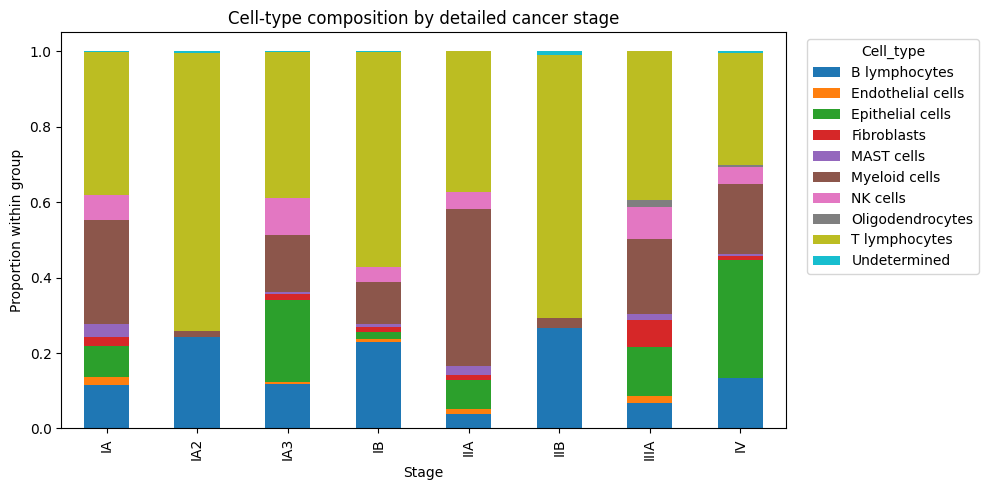

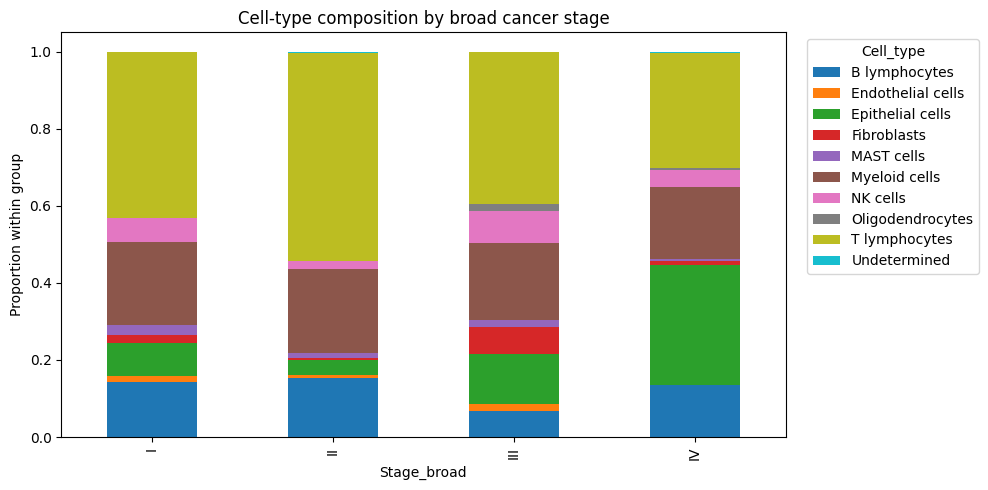

In [99]:

if meta is not None:
    stage_levels = ["IA", "IA2", "IA3", "IB", "IIA", "IIB", "IIIA", "IV"]
    meta["Stage"] = pd.Categorical(meta["Stage"], categories=stage_levels, ordered=True)

    possible_celltype_cols = [
        "Cell_type", "CellType", "cell_type", "Major_cell_type", "MajorCellType",
        "Annotation", "annotation", "Cell_subtype", "Cell_subtype_1"
    ]
    celltype_col = next((c for c in possible_celltype_cols if c in meta.columns), None)
    if celltype_col is None:
        raise ValueError("Could not automatically find a cell-type column in the metadata.")

    patient_stage = meta[["Patient", "Stage"]].drop_duplicates().groupby("Stage", observed=False).size().reset_index(name="n_patients")
    cell_stage = meta.groupby("Stage", observed=False).size().reset_index(name="n_cells")

    print("Using cell-type column:", celltype_col)
    display(cell_stage)
    display(patient_stage)

    meta["Stage_broad"] = np.select(
        [
            meta["Stage"].astype(str).isin(["IA", "IA2", "IA3", "IB"]),
            meta["Stage"].astype(str).isin(["IIA", "IIB"]),
            meta["Stage"].astype(str).eq("IIIA"),
            meta["Stage"].astype(str).eq("IV"),
        ],
        ["I", "II", "III", "IV"],
        default=None,
    )
    meta["Stage_group"] = np.select(
        [meta["Stage_broad"].isin(["I", "II"]), meta["Stage_broad"].isin(["III", "IV"])],
        ["Early", "Advanced"],
        default=None,
    )

    plot_stacked_proportions(
        meta.dropna(subset=["Stage", celltype_col]),
        "Stage", celltype_col,
        "Cell-type composition by detailed cancer stage",
        "celltype_composition_by_detailed_stage.png",
    )

    plot_stacked_proportions(
        meta.dropna(subset=["Stage_broad", celltype_col]),
        "Stage_broad", celltype_col,
        "Cell-type composition by broad cancer stage",
        "celltype_composition_by_broad_stage.png",
    )



## 3. Load or create the MMIL modeling table

The modeling table contains one row per cell, patient/stage metadata, and PC features. In the original R pipeline, this is created by the preprocessing script and saved as:

`Data/GSE131907_stage_pilot_PCs_metadata.csv`

For a clean final notebook, we load the preprocessed file when it exists. The optional preprocessing cell below shows the Python version of the preprocessing logic, but the fastest path is to reuse the saved PC file.


In [100]:

model_file = data_dir / "GSE131907_stage_pilot_PCs_metadata.csv"

if model_file.exists():
    model_df = pd.read_csv(model_file)
    print("Loaded preprocessed modeling table:", model_df.shape)
else:
    model_df = None
    print("Preprocessed modeling table not found:", model_file)
    print("Run the optional Python preprocessing cell below, or run the original preprocessing script once.")


Loaded preprocessed modeling table: (7000, 31)


In [101]:

# Optional Python preprocessing version of 03_preprocess_MMIL.R.
# This cell is hidden because most runs should directly load GSE131907_stage_pilot_PCs_metadata.csv.
# It requires pyreadr to read the RDS expression file.

if model_df is None:
    try:
        import pyreadr
    except ImportError as e:
        raise ImportError(
            "pyreadr is needed only if you want Python to read the RDS expression file. "
            "Install it with: pip install pyreadr. Otherwise, use the preprocessed CSV."
        ) from e

    expr_file = data_dir / "GSE131907_pilot_expression_subset_dt.rds"
    pilot_meta_file = data_dir / "GSE131907_pilot_sampled_cell_metadata_with_clinical.csv"
    expr_obj = pyreadr.read_r(str(expr_file))
    expr_dt = next(iter(expr_obj.values()))
    meta_pilot = pd.read_csv(pilot_meta_file)

    gene_names = expr_dt.iloc[:, 0].astype(str).to_numpy()
    cell_ids = expr_dt.columns[1:].astype(str)
    expr_mat = expr_dt.iloc[:, 1:].to_numpy(float)  # genes x cells

    meta_pilot = meta_pilot.set_index("Index").loc[cell_ids].reset_index()
    meta_pilot["Stage_broad"] = np.select(
        [
            meta_pilot["Stage"].isin(["IA", "IA2", "IA3", "IB"]),
            meta_pilot["Stage"].isin(["IIA", "IIB"]),
            meta_pilot["Stage"].eq("IIIA"),
            meta_pilot["Stage"].eq("IV"),
        ],
        ["I", "II", "III", "IV"],
        default=None,
    )
    meta_pilot["Stage_group"] = np.select(
        [meta_pilot["Stage_broad"].isin(["I", "II"]), meta_pilot["Stage_broad"].isin(["III", "IV"])],
        ["Early", "Advanced"],
        default=None,
    )

    keep_cells = meta_pilot["Stage_group"].notna().to_numpy()
    expr_mat = expr_mat[:, keep_cells]
    meta_pilot = meta_pilot.loc[keep_cells].reset_index(drop=True)
    cell_ids = np.asarray(cell_ids)[keep_cells]

    min_cells = int(np.ceil(0.01 * expr_mat.shape[1]))
    keep_genes = (expr_mat > 0).sum(axis=1) >= min_cells
    expr_filt = expr_mat[keep_genes, :]
    gene_names_filt = gene_names[keep_genes]

    lib_size = expr_filt.sum(axis=0)
    expr_norm = (expr_filt / lib_size) * 10000
    expr_log = np.log1p(expr_norm)

    gene_means = expr_log.mean(axis=1)
    gene_vars = expr_log.var(axis=1, ddof=1)
    dispersion = gene_vars / (gene_means + 1e-8)
    n_hvg = min(2000, expr_log.shape[0])
    hvg_idx = np.argsort(-dispersion)[:n_hvg]
    expr_hvg = expr_log[hvg_idx, :]

    pca = PCA(n_components=20, random_state=RANDOM_STATE)
    pc_mat = pca.fit_transform(StandardScaler().fit_transform(expr_hvg.T))
    pc_cols = [f"PC{i+1}" for i in range(pc_mat.shape[1])]

    model_df = pd.DataFrame({
        "Cell": cell_ids,
        "Patient": meta_pilot["Patient"].to_numpy(),
        "Sample": meta_pilot.get("Sample", pd.Series([np.nan] * len(meta_pilot))).to_numpy(),
        "Tissue": meta_pilot.get("Tissue", pd.Series([np.nan] * len(meta_pilot))).to_numpy(),
        "Sample_Origin": meta_pilot.get("Sample_Origin", pd.Series([np.nan] * len(meta_pilot))).to_numpy(),
        "Stage": meta_pilot["Stage"].to_numpy(),
        "Stage_broad": meta_pilot["Stage_broad"].to_numpy(),
        "Stage_group": meta_pilot["Stage_group"].to_numpy(),
        "Cell_type": meta_pilot["Cell_type"].to_numpy(),
        "Cell_type_refined": meta_pilot.get("Cell_type.refined", pd.Series([np.nan] * len(meta_pilot))).to_numpy(),
        "Cell_subtype": meta_pilot.get("Cell_subtype", pd.Series([np.nan] * len(meta_pilot))).to_numpy(),
    })
    model_df = pd.concat([model_df, pd.DataFrame(pc_mat, columns=pc_cols)], axis=1)
    model_df.to_csv(model_file, index=False)
    print("Saved preprocessed modeling table:", model_file)


In [102]:

if model_df is None:
    raise FileNotFoundError("No modeling table loaded. Please create GSE131907_stage_pilot_PCs_metadata.csv first.")

pc_cols = [c for c in model_df.columns if c.startswith("PC")]
required = ["Patient", "Stage_group", "Stage_broad", "Cell_type"]
missing = [c for c in required if c not in model_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

model_df = model_df.dropna(subset=["Patient", "Stage_group"] + pc_cols).copy()
model_df["Stage_group"] = pd.Categorical(model_df["Stage_group"], categories=["Early", "Advanced"], ordered=True)
model_df["y_patient"] = (model_df["Stage_group"].astype(str) == "Advanced").astype(int)
model_df["z_obs"] = model_df["y_patient"]

print("Modeling table shape:", model_df.shape)
print("Number of PC features:", len(pc_cols))
display(model_df.head())

display(model_df.groupby("Stage_group", observed=False).size().reset_index(name="n_cells"))
display(model_df[["Patient", "Stage_group"]].drop_duplicates().groupby("Stage_group", observed=False).size().reset_index(name="n_patients"))


Modeling table shape: (7000, 33)
Number of PC features: 20


,Cell,Patient,Sample,Tissue,Sample_Origin,Stage,Stage_broad,Stage_group,Cell_type,Cell_type_refined,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,y_patient,z_obs
0,TCAGGTATCTGGGCCA_NS_07,P3007,NS_07,mBrain,mBrain,IV,IV,Advanced,Epithelial cells,Epithelial cells,...,0.584701,0.454798,-2.859771,-2.266230,2.351900,-0.403348,-5.475006,-0.944744,1,1
1,CTAATGGGTGAAATCA_NS_03,P3003,NS_03,mBrain,mBrain,IV,IV,Advanced,Epithelial cells,Epithelial cells,...,0.604579,1.982500,1.900841,10.528046,-3.575497,0.704203,-10.480866,-6.715893,1,1
2,ACGATACAGGTGCTTT_NS_07,P3007,NS_07,mBrain,mBrain,IV,IV,Advanced,Epithelial cells,Epithelial cells,...,1.931597,0.443540,-4.062543,-4.849311,2.605247,-0.995625,-3.688974,0.196955,1,1
3,CTAATGGGTATAAACG_NS_13,P3013,NS_13,mBrain,mBrain,IV,IV,Advanced,MAST cells,MAST cells,...,-2.456385,1.857120,0.495896,1.607176,-0.446155,-0.384290,-0.529209,-1.168750,1,1
4,CGTCACTGTCTTGTCC_NS_03,P3003,NS_03,mBrain,mBrain,IV,IV,Advanced,Epithelial cells,Epithelial cells,...,-0.749782,2.116765,2.611208,12.130804,-3.774688,1.232538,-9.288397,-5.984939,1,1


,Stage_group,n_cells
0,Early,2580
1,Advanced,4420


,Stage_group,n_patients
0,Early,20
1,Advanced,24


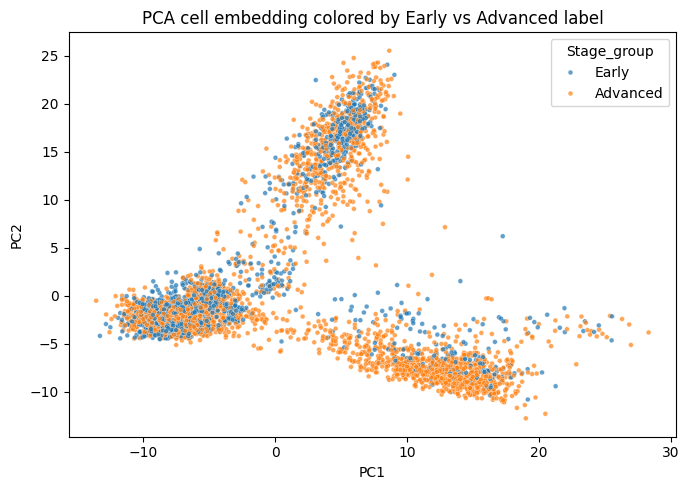

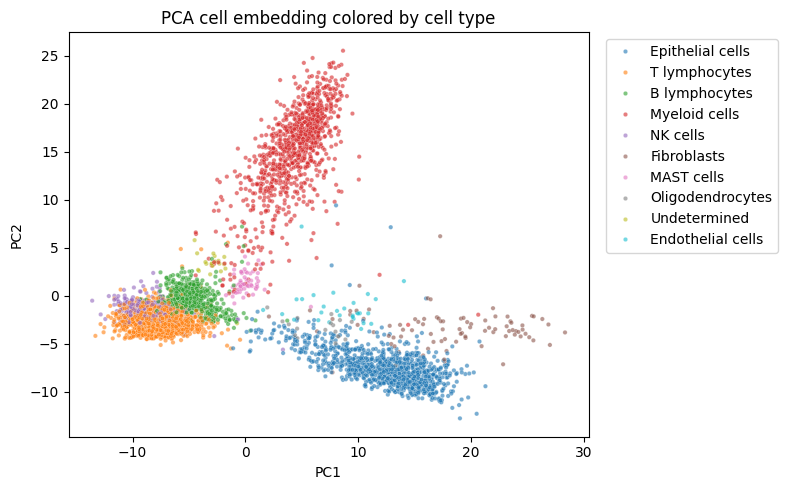

In [103]:

plt.figure(figsize=(7, 5))
sns.scatterplot(data=model_df.sample(min(len(model_df), 5000), random_state=RANDOM_STATE),
                x="PC1", y="PC2", hue="Stage_group", s=12, alpha=0.7)
plt.title("PCA cell embedding colored by Early vs Advanced label")
savefig("pca_by_stage_group.png")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=model_df.sample(min(len(model_df), 5000), random_state=RANDOM_STATE),
                x="PC1", y="PC2", hue="Cell_type", s=10, alpha=0.6)
plt.title("PCA cell embedding colored by cell type")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("pca_by_cell_type.png")



## 4. Method overview

The key weak-supervision setup is:

- **Bag** = patient/sample
- **Instance** = cell
- **Observed label** = patient-level cancer stage
- **Latent label** = cell-level stage-associated state

Binary models:

1. **Naive inherited-label baseline**: every cell inherits its patient's Early/Advanced label.
2. **Deterministic EM-MMIL**: Advanced patients are treated as mixtures of baseline-like and advanced-associated cells.
3. **MCEM-MMIL**: the E-step samples latent cell labels and averages them over Monte Carlo samples.
4. **Noisy-OR MMIL**: a more paper-style bag-level likelihood:

\[
P(Y_j = \mathrm{Advanced}) = 1 - \prod_{i \in j} (1 - p_i),
\]

where \(p_i\) is the inferred probability that cell \(i\) is advanced-associated.



## 5. Binary Early vs Advanced MMIL results


In [104]:

binary_df = split_patients_stratified(
    model_df,
    patient_col="Patient",
    label_col="y_patient",
    test_frac=0.25,
    random_state=RANDOM_STATE,
)

patient_split, cell_split = summarize_split(binary_df, patient_col="Patient", label_col="Stage_group")
display(patient_split)
display(cell_split)


,split,Stage_group,n_patients
0,test,Early,5
1,test,Advanced,6
2,train,Early,15
3,train,Advanced,18


,split,Stage_group,n_cells
0,test,Early,611
1,test,Advanced,731
2,train,Early,1969
3,train,Advanced,3689


In [105]:

binary_cell_pred, binary_logs, binary_models = fit_binary_naive_em_mcem(
    binary_df,
    pc_cols=pc_cols,
    rho=0.70,
    max_iter=30,
    mcem_samples=20,
    lambda_grid=[0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    random_state=RANDOM_STATE,
)

binary_cell_pred.to_csv(results_dir / "python_stage_binary_MMIL_MCEM_cell_predictions.csv", index=False)
binary_logs["em_log"].to_csv(results_dir / "python_stage_binary_EM_MMIL_log.csv", index=False)
binary_logs["mcem_log"].to_csv(results_dir / "python_stage_binary_MCEM_MMIL_log.csv", index=False)
binary_logs["lambda_tuning"].to_csv(results_dir / "python_stage_binary_lambda_tuning.csv", index=False)

print("Selected binary ridge lambda:", binary_logs["best_lambda"])
display(binary_logs["lambda_tuning"])


Selected binary ridge lambda: 0.003


,lambda,validation_logloss,converged
1,0.003,0.497142,True
0,0.001,0.497319,True
2,0.010,0.497840,True
3,0.030,0.503642,True
4,0.100,0.525081,True
5,0.300,0.561374,True
6,1.000,0.604301,True


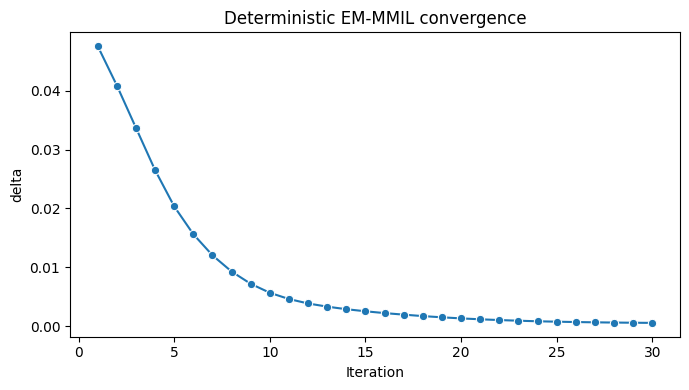

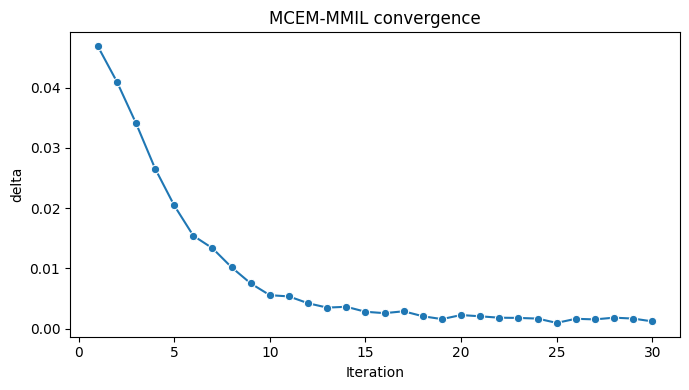

In [106]:

plot_convergence(binary_logs["em_log"], "delta", "Deterministic EM-MMIL convergence", "binary_em_convergence.png")
plot_convergence(binary_logs["mcem_log"], "delta", "MCEM-MMIL convergence", "binary_mcem_convergence.png")


In [107]:

prob_cols = {
    "Naive inherited-label classifier": "naive_prob",
    "Deterministic EM-MMIL": "em_mmil_prob",
    "MCEM-MMIL": "mcem_mmil_prob",
}
patient_scores = aggregate_patient_scores(binary_cell_pred, prob_cols)
metrics = patient_level_metrics(patient_scores)

patient_scores.to_csv(results_dir / "python_patient_level_binary_MMIL_aggregation_scores.csv", index=False)
metrics.to_csv(results_dir / "python_patient_level_binary_MMIL_metrics.csv", index=False)

display(metrics.sort_values(["split", "aggregation", "model"]))


,split,model,aggregation,n_patients,n_early,n_advanced,auroc,logloss,brier
0,test,Deterministic EM-MMIL,mean_prob,11,5,6,0.766667,1.625778,0.453365
6,test,MCEM-MMIL,mean_prob,11,5,6,0.766667,1.631123,0.453504
12,test,Naive inherited-label classifier,mean_prob,11,5,6,0.700000,0.642357,0.222474
1,test,Deterministic EM-MMIL,median_prob,11,5,6,0.566667,2.442670,0.505702
7,test,MCEM-MMIL,median_prob,11,5,6,0.566667,2.456157,0.504178
13,test,Naive inherited-label classifier,median_prob,11,5,6,0.700000,0.660013,0.227354
4,test,Deterministic EM-MMIL,prop_gt_0_5,11,5,6,0.800000,1.956943,0.475297
10,test,MCEM-MMIL,prop_gt_0_5,11,5,6,0.900000,1.955927,0.475286
16,test,Naive inherited-label classifier,prop_gt_0_5,11,5,6,0.700000,0.674410,0.224227
5,test,Deterministic EM-MMIL,prop_gt_0_9,11,5,6,0.833333,4.879181,0.522246


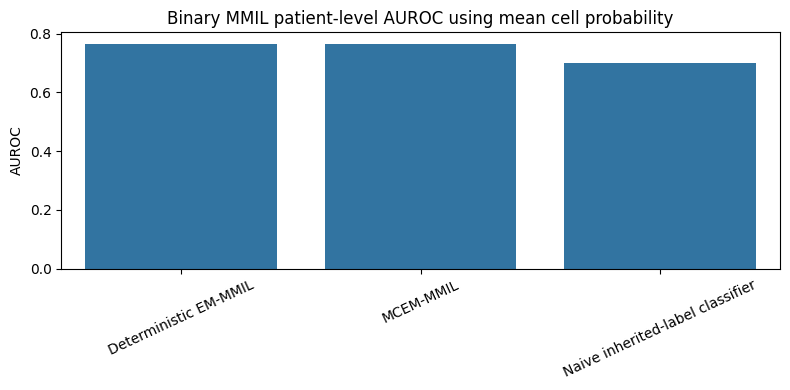

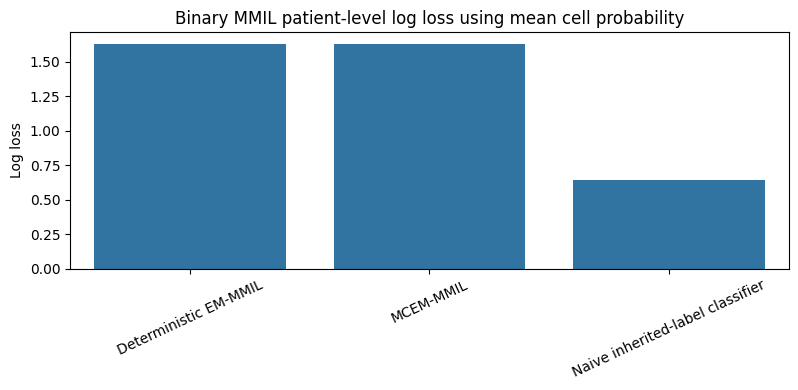

In [108]:

main_metric = metrics[(metrics["split"] == "test") & (metrics["aggregation"] == "mean_prob")].copy()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=main_metric, x="model", y="auroc", ax=ax)
ax.set_title("Binary MMIL patient-level AUROC using mean cell probability")
ax.set_xlabel("")
ax.set_ylabel("AUROC")
ax.tick_params(axis="x", rotation=25)
savefig("binary_model_comparison_auroc.png")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=main_metric, x="model", y="logloss", ax=ax)
ax.set_title("Binary MMIL patient-level log loss using mean cell probability")
ax.set_xlabel("")
ax.set_ylabel("Log loss")
ax.tick_params(axis="x", rotation=25)
savefig("binary_model_comparison_logloss.png")


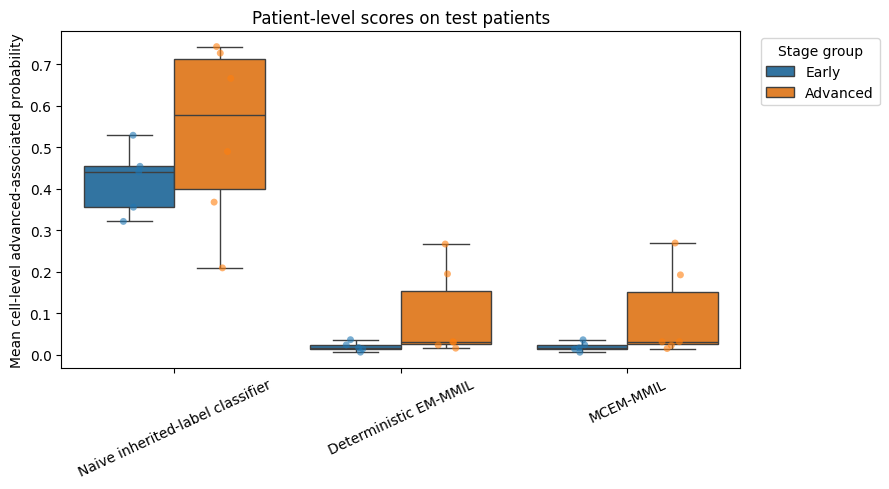

In [109]:

plot_df = patient_scores[(patient_scores["split"] == "test") & (patient_scores["model"].isin(prob_cols.keys()))]
plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="model", y="mean_prob", hue="Stage_group")
sns.stripplot(data=plot_df, x="model", y="mean_prob", hue="Stage_group", dodge=True, alpha=0.6)
plt.title("Patient-level scores on test patients")
plt.xlabel("")
plt.ylabel("Mean cell-level advanced-associated probability")
plt.xticks(rotation=25)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Stage group", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("binary_patient_scores_by_model.png")



### 5.1 Paper-style noisy-OR MMIL

This model is closer to the original MMIL paper idea because the patient-level label is modeled directly through a bag-level likelihood over all cells in the patient.


In [110]:

effective_bag_size_cap = 100
noisy_lambda_grid = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]

noisy_df = split_train_validation_by_patient(
    binary_df,
    patient_col="Patient",
    label_col="y_patient",
    val_frac=0.20,
    random_state=RANDOM_STATE,
)

subtrain_df = noisy_df[noisy_df["model_split"] == "subtrain"].copy()
validation_df = noisy_df[noisy_df["model_split"] == "validation"].copy()
train_df = noisy_df[noisy_df["split"] == "train"].copy()

best_noisy_lambda, noisy_tuning, _ = tune_noisy_or_lambda(
    subtrain_df,
    validation_df,
    pc_cols,
    lambda_grid=noisy_lambda_grid,
    effective_bag_size_cap=effective_bag_size_cap,
)

print("Selected noisy-OR lambda:", best_noisy_lambda)
display(noisy_tuning)
noisy_tuning.to_csv(results_dir / "python_stage_binary_noisyOR_lambda_tuning.csv", index=False)

noisy_model, noisy_res = fit_noisy_or_mmil(
    train_df,
    pc_cols,
    lambda_ridge=best_noisy_lambda,
    effective_bag_size_cap=effective_bag_size_cap,
)
print("Noisy-OR optimization converged:", noisy_res.success)


Selected noisy-OR lambda: 0.3


,lambda,validation_logloss,validation_auroc,converged
5,0.300,0.491988,0.916667,True
4,0.100,0.535038,0.916667,True
3,0.030,0.550971,0.833333,True
6,1.000,0.579914,0.750000,True
7,3.000,0.650989,0.583333,True
2,0.010,0.691118,0.833333,True
8,10.000,0.699018,0.583333,True
1,0.003,0.829763,0.833333,True
0,0.001,0.970046,0.833333,True


Noisy-OR optimization converged: True


In [111]:

noisy_cell_prob = noisy_model.predict_cell_proba(noisy_df[pc_cols].to_numpy(float))
noisy_cell_pred = noisy_df.copy()
noisy_cell_pred["noisyOR_cell_prob"] = noisy_cell_prob
noisy_patient_pred = predict_noisy_or_patient_scores(noisy_df, noisy_cell_prob, effective_bag_size_cap)

noisy_cell_pred.to_csv(results_dir / "python_stage_binary_noisyOR_cell_predictions.csv", index=False)
noisy_patient_pred.to_csv(results_dir / "python_stage_binary_noisyOR_patient_predictions.csv", index=False)

noisy_metrics = []
for split, g in noisy_patient_pred.groupby("split"):
    noisy_metrics.append({
        "split": split,
        "model": "Paper-style noisy-OR MMIL",
        "score": "noisyOR_patient_prob",
        "n_patients": len(g),
        "auroc": safe_auc(g["y_patient"], g["noisyOR_patient_prob"]),
        "logloss": safe_log_loss(g["y_patient"], g["noisyOR_patient_prob"]),
        "brier": brier_score_loss(g["y_patient"], np.clip(g["noisyOR_patient_prob"], EPS, 1 - EPS)),
    })
noisy_metrics = pd.DataFrame(noisy_metrics)
noisy_metrics.to_csv(results_dir / "python_stage_binary_noisyOR_metrics.csv", index=False)
display(noisy_metrics)


,split,model,score,n_patients,auroc,logloss,brier
0,test,Paper-style noisy-OR MMIL,noisyOR_patient_prob,11,0.933333,0.471543,0.148506
1,train,Paper-style noisy-OR MMIL,noisyOR_patient_prob,33,0.992593,0.369535,0.107426


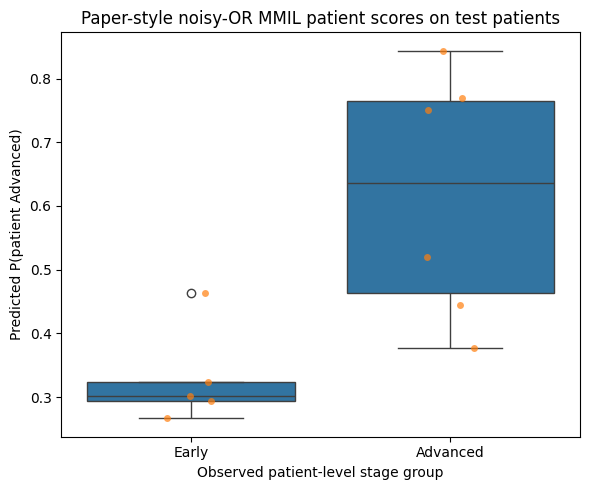

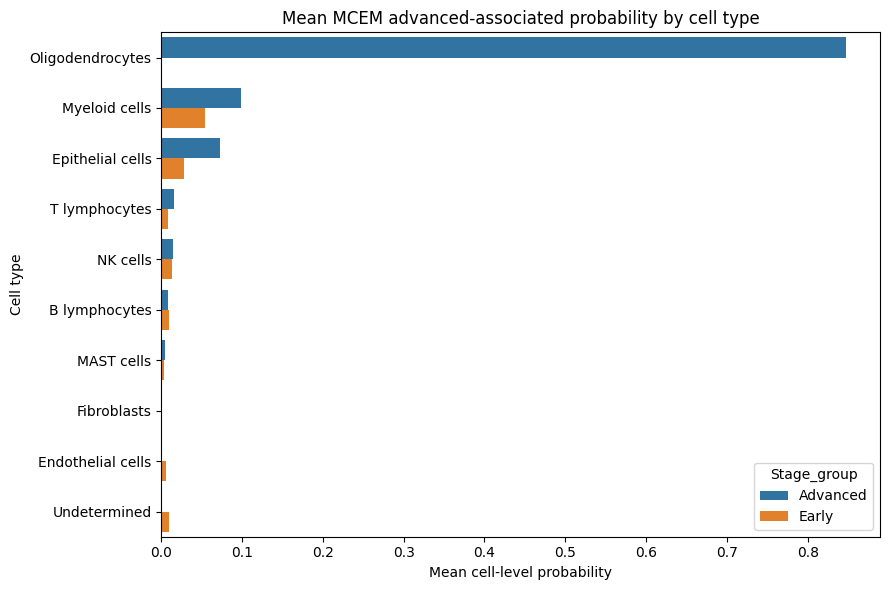

In [112]:

plt.figure(figsize=(6, 5))
sns.boxplot(data=noisy_patient_pred[noisy_patient_pred["split"] == "test"],
            x="Stage_group", y="noisyOR_patient_prob")
sns.stripplot(data=noisy_patient_pred[noisy_patient_pred["split"] == "test"],
              x="Stage_group", y="noisyOR_patient_prob", alpha=0.7)
plt.title("Paper-style noisy-OR MMIL patient scores on test patients")
plt.xlabel("Observed patient-level stage group")
plt.ylabel("Predicted P(patient Advanced)")
savefig("noisyOR_patient_scores_test.png")

celltype_summary = summarize_celltypes(binary_cell_pred, "mcem_mmil_prob", "MCEM-MMIL")
celltype_summary.to_csv(results_dir / "python_stage_binary_MCEM_celltype_summary.csv", index=False)

plt.figure(figsize=(9, 6))
plot_ct = celltype_summary[celltype_summary["split"] == "test"].copy()
sns.barplot(data=plot_ct, y="Cell_type", x="mean_prob", hue="Stage_group")
plt.title("Mean MCEM advanced-associated probability by cell type")
plt.xlabel("Mean cell-level probability")
plt.ylabel("Cell type")
savefig("binary_mcem_celltype_summary.png")



## 6. Categorical stage extension

The categorical extension uses three labels:

- `I`
- `II_III`
- `IV`

This is less directly tied to classic binary MIL, but it is useful as a project extension: each cell gets a probability vector over latent stage-associated states.


In [113]:

cat_df = model_df.copy()
cat_df["Stage_cat"] = np.select(
    [
        cat_df["Stage_broad"].astype(str).eq("I"),
        cat_df["Stage_broad"].astype(str).isin(["II", "III"]),
        cat_df["Stage_broad"].astype(str).eq("IV"),
    ],
    ["I", "II_III", "IV"],
    default=None,
)
cat_df = cat_df.dropna(subset=["Stage_cat"]).copy()
cat_df["Stage_cat"] = pd.Categorical(cat_df["Stage_cat"], categories=["I", "II_III", "IV"], ordered=True)

cat_df = split_patients_stratified(
    cat_df,
    patient_col="Patient",
    label_col="Stage_cat",
    test_frac=0.25,
    random_state=RANDOM_STATE,
)

display(cat_df[["Patient", "Stage_cat", "split"]].drop_duplicates().groupby(["split", "Stage_cat"], observed=False).size().reset_index(name="n_patients"))
display(cat_df.groupby(["split", "Stage_cat"], observed=False).size().reset_index(name="n_cells"))


,split,Stage_cat,n_patients
0,test,I,4
1,test,II_III,2
2,test,IV,5
3,train,I,13
4,train,II_III,5
5,train,IV,15


,split,Stage_cat,n_cells
0,test,I,585
1,test,II_III,273
2,test,IV,1350
3,train,I,1671
4,train,II_III,561
5,train,IV,2560


In [114]:

cat_pred, cat_logs, cat_models = fit_categorical_em_mcem(
    cat_df,
    pc_cols=pc_cols,
    label_strength=0.70,
    max_iter=40,
    mcem_samples=30,
    lambda_ridge=0.01,
    random_state=RANDOM_STATE,
)

class_levels = cat_logs["class_levels"]
cat_metrics = evaluate_categorical_predictions(cat_pred, class_levels)
cat_pred.to_csv(results_dir / "python_stage_categorical_MMIL_MCEM_cell_predictions.csv", index=False)
cat_logs["em_log"].to_csv(results_dir / "python_stage_categorical_EM_log.csv", index=False)
cat_logs["mcem_log"].to_csv(results_dir / "python_stage_categorical_MCEM_log.csv", index=False)
cat_metrics.to_csv(results_dir / "python_stage_categorical_metrics.csv", index=False)

display(cat_metrics)


,split,model,n_cells,logloss,accuracy
0,test,Naive categorical baseline,2208,1.488021,0.450634
1,test,Categorical EM-MMIL,2208,1.340260,0.564312
2,test,Categorical MCEM-MMIL,2208,1.325154,0.565670
3,train,Naive categorical baseline,4792,0.692166,0.716611
4,train,Categorical EM-MMIL,4792,0.829265,0.715776
5,train,Categorical MCEM-MMIL,4792,0.835809,0.716194


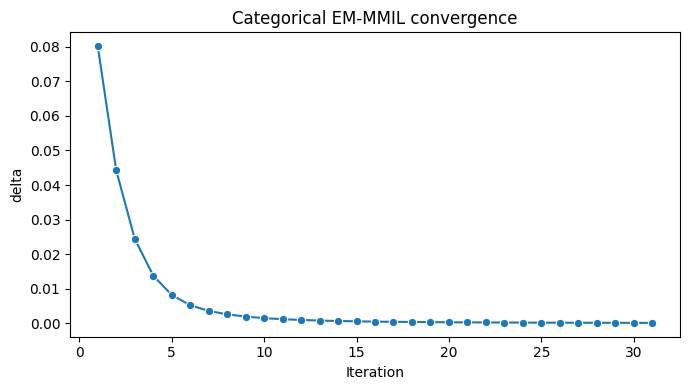

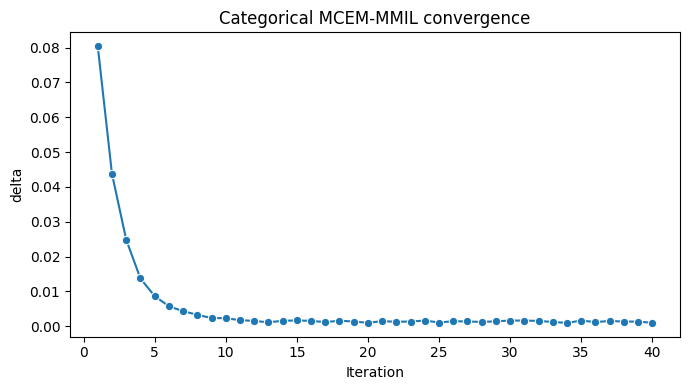

In [115]:

plot_convergence(cat_logs["em_log"], "delta", "Categorical EM-MMIL convergence", "categorical_em_convergence.png")
plot_convergence(cat_logs["mcem_log"], "delta", "Categorical MCEM-MMIL convergence", "categorical_mcem_convergence.png")


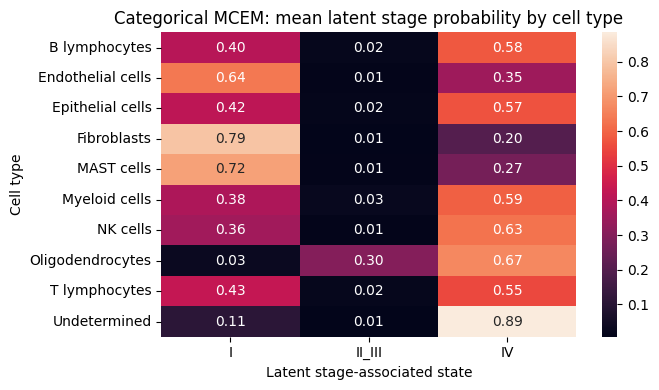

In [116]:

# Cell-type-stage association heatmap using MCEM probabilities.
heat_rows = []
for c in class_levels:
    col = f"mcem_cat_prob_{c}"
    tmp = (
        cat_pred[cat_pred["split"] == "test"]
        .groupby("Cell_type", as_index=False)[col]
        .mean()
        .rename(columns={col: "mean_prob"})
    )
    tmp["latent_stage"] = c
    heat_rows.append(tmp)
heat = pd.concat(heat_rows, ignore_index=True)
heat_mat = heat.pivot(index="Cell_type", columns="latent_stage", values="mean_prob").fillna(0)

plt.figure(figsize=(7, max(4, 0.35 * len(heat_mat))))
sns.heatmap(heat_mat, annot=True, fmt=".2f")
plt.title("Categorical MCEM: mean latent stage probability by cell type")
plt.xlabel("Latent stage-associated state")
plt.ylabel("Cell type")
savefig("categorical_mcem_celltype_stage_heatmap.png")



## 7. Summary and discussion

Main takeaways:

- The pipeline uses patient-level cancer stage labels as weak supervision to infer latent cell-level stage-associated probabilities.
- The deterministic EM model gives a practical MMIL-inspired baseline.
- MCEM adds Monte Carlo sampling of latent cell labels in the E-step.
- The noisy-OR model is the most paper-style binary MMIL comparison because the patient-level likelihood is directly defined through all cells in each patient.
- The categorical model extends the idea to Stage I / II-III / IV latent states.

Important limitations:

- Cell-level stage labels are latent; there is no direct cell-level gold standard.
- The models use PCA features rather than the full gene expression matrix.
- The simplified EM/MCEM models use weak-label constraints rather than the full original MMIL likelihood.
- Noisy-OR can saturate for patients with many cells, so this notebook uses an effective bag-size cap by default.



## 8. Output files

The notebook writes tables to `Results/` and figures to `Results/Figures/`. Key outputs include:

- `python_stage_binary_MMIL_MCEM_cell_predictions.csv`
- `python_patient_level_binary_MMIL_metrics.csv`
- `python_stage_binary_noisyOR_cell_predictions.csv`
- `python_stage_binary_noisyOR_metrics.csv`
- `python_stage_categorical_MMIL_MCEM_cell_predictions.csv`
- `python_stage_categorical_metrics.csv`
